<center>

# Analytical creation of Na2Ca3Al2F14 sample

</center>

#### Author: Daniel Lomholt Christensen

In [1]:
# Brug uden absorption i powdern

# Test absorption in Union

# Evt. samme test som incoherent.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mcstasscript as ms

In [2]:
# # Load the powder structure and generate the theoretical diffractogram
# Load in Structure factor from Vesta

def get_formfact(file):
    data_from_cif = pd.read_table(file, sep=r'\s+', header=0)
    # data_from_cif = pd.read_table("Copper.txt", sep=r'\s+', header=0)

    cif = np.array([data_from_cif['2θ'],data_from_cif['|F|'],data_from_cif['M'], data_from_cif['d(Å)']] )

    theta_list = {}
    for i in range(len(cif[0])):
        if cif[0,i]>100 or np.isnan(cif[0,i]):
            continue
        # print(cif[3,i])
        
        form_factor = cif[1,i]**2
        # print(f"|F|={form_factor/100:.3f}\tmult={cif[2,i]}\tQ = {2*np.pi/cif[3,i]:.6f}\tTheta={cif[0,i]:.4g}")
        if cif[0,i] not in theta_list.keys():
            theta_list[cif[0,i]] = form_factor*cif[2,i]
            
        else:
            theta_list[cif[0,i]] += form_factor*cif[2,i]

    arr = np.zeros((len(theta_list),2))

    for i, (k, v) in enumerate(theta_list.items()):
        arr[i,:] = np.array((k,v))
    cif = arr.T
    return cif

# Scale the cif pattern 
def  n_measured(flux,A, dist,h, unit_cell_vol, wavelength, r,pattern):
    form_factor = pattern[1]/100
    # print(np.sqrt(form_factor))
    deb_prop = h/(2*np.sin(pattern[0]*np.pi/180)*r*np.pi)

    cross_section = 1 / unit_cell_vol**2 * wavelength**3 /4 /np.sin( pattern[0]*np.pi/180/2)*form_factor
    # cross_section = 
    result = flux * A * dist * deb_prop * cross_section # A * dist er basically bare V som ellers indgaar i spredninstvaersnit
    return np.array([pattern[0], result])

flux = 1.56009 * 1e6 # n/s/cm^2
A = 1 # cm^2
dist = 0.1 # cm
vol = 0.1 # cm^3
h = 0.1 # cm
r = 100 # cm
unit_cell_vol = 1079.1 # AA^3=10^-24 cm
wavelength = 2.567 # AA
rho = 1/unit_cell_vol # AA^-3

nacalf_analytical = get_formfact('./NaCaAlF_no_debye.txt')
nacalf_F = nacalf_analytical[1]


Qs = [0.866313, 1.22515, 1.5005, 1.73262, 1.93713, 1.93713, 2.12202, 2.29205, 2.29205, 2.4503,
 2.59894, 2.59894, 2.73953, 2.73953, 2.87323, 3.001, 3.12354, 3.12354, 3.12354, 3.12354,
 3.35522, 3.35522, 3.46525, 3.5719, 3.5719, 3.5719, 3.67545, 3.67545]
F_from_mcstas = [11.005968, 101.1966, 211.16448, 504.5256, 90.87684, 19.14468, 205.7728,
 103.83912, 249.0816, 377.172, 5.97114, 933.792, 735.3348, 696.426,
 3874.632, 80.67, 2568.696, 162.1176, 40.83948, 1237.2408, 2706.768,
 1340.2824, 3247.632, 11.619804, 307.0572, 145.16496, 242.9064, 837.3408]


Fs = []
for i, refl in enumerate(Qs):
    if Qs[i-1] == refl:
        Fs[-1] += F_from_mcstas[i]
    else:
        Fs.append(F_from_mcstas[i])

Fs = np.array(Fs)


nacalf_McStas = nacalf_analytical.copy()
nacalf_McStas[1] = Fs*100
nacalf_McStas = n_measured(flux, A, dist,h, unit_cell_vol, wavelength,r, nacalf_McStas)
nacalf_analytical = n_measured(flux, A, dist,h, unit_cell_vol, wavelength,r, nacalf_analytical)

for i in range(len(Fs)):
    print(f'Mcstas = {Fs[i]:.5f}\tAnalytical_Vesta={nacalf_F[i]/100:.5f}')


Mcstas = 11.00597	Analytical_Vesta=11.00590
Mcstas = 101.19660	Analytical_Vesta=101.19681
Mcstas = 211.16448	Analytical_Vesta=211.16449
Mcstas = 504.52560	Analytical_Vesta=504.52575
Mcstas = 110.02152	Analytical_Vesta=110.02152
Mcstas = 205.77280	Analytical_Vesta=205.77307
Mcstas = 352.92072	Analytical_Vesta=352.92136
Mcstas = 377.17200	Analytical_Vesta=377.17143
Mcstas = 939.76314	Analytical_Vesta=939.76078
Mcstas = 1431.76080	Analytical_Vesta=1431.76014
Mcstas = 3874.63200	Analytical_Vesta=3874.61846
Mcstas = 80.67000	Analytical_Vesta=80.67077
Mcstas = 4008.89388	Analytical_Vesta=4008.90292
Mcstas = 4047.05040	Analytical_Vesta=4047.05777
Mcstas = 3247.63200	Analytical_Vesta=3247.62481
Mcstas = 463.84196	Analytical_Vesta=463.84241
Mcstas = 1080.24720	Analytical_Vesta=1080.24735


In [3]:
# Load the data and generate the simulated diffractogram
data = ms.load_data("../data/powder_nacalf_no_debye")
data = data[-1]
print(data)
# split the data up into peaks
data_int = []
mask_areas = []
errs = []
for pos in nacalf_analytical[0]:
    mask = (data.xaxis>(pos-1.5)) & (data.xaxis<(pos+1.5))
    mask_areas.append(data.xaxis[mask])
    intensity = np.sum(data.Intensity[mask])
    errs.append(np.sqrt(np.sum(data.Error**2)))
    data_int.append(intensity)


data_int = np.array(data_int)
print(f"Mcstas={data_int}\nAnalytical={nacalf_analytical[1]}\n")

McStasData: banana_mon type: 1D  I:3.42121 E:0.00463985 N:1360410.0
Mcstas=[0.01610048 0.07550354 0.10714202 0.19555947 0.03471844 0.05511394
 0.08232906 0.07857453 0.17648762 0.24745243 0.62635423 0.01226346
 0.57615907 0.53689034 0.41324178 0.05732077 0.13000202]
Analytical=[0.01618533 0.0756359  0.10701039 0.19513776 0.03466509 0.05505345
 0.08252934 0.07875957 0.1781679  0.24976526 0.62885419 0.0122967
 0.57864688 0.53504435 0.41482761 0.05757873 0.13105806]



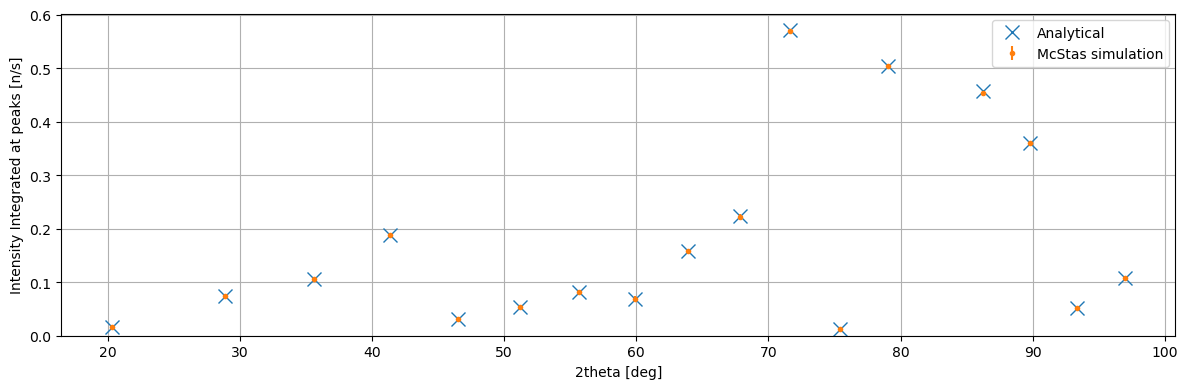

In [8]:

fig, ax = plt.subplots(figsize=(12,4), ncols=1)

# ax2 = ax.twinx()
ax.plot(nacalf_analytical[0], nacalf_analytical[1], 'x',markersize=10,label='Analytical')

ax.errorbar(nacalf_analytical[0], data_int,yerr=errs, fmt='.', label='McStas simulation')

# ax2.errorbar(data.xaxis, data.Intensity, fmt='k-', label='McStas')


ax.legend()

ax.set(ylim=(0))
# ax2.set(ylim=(0,0.4))
ax.grid(True)
ax.set(xlabel="2theta [deg]",ylabel="Intensity Integrated at peaks [n/s]")
# ax2.set(ylabel="Intensity [n/s] simulation output")
fig.tight_layout()
# fig.savefig('')


In [5]:
# # Load the powder structure and generate the theoretical diffractogram
# Load in Structure factor from Vesta

def get_formfact(file):
    data_from_cif = pd.read_table(file, sep=r'\s+', header=0)
    # data_from_cif = pd.read_table("Copper.txt", sep=r'\s+', header=0)

    cif = np.array([data_from_cif['2θ'],data_from_cif['|F|'],data_from_cif['M'], data_from_cif['d(Å)']] )

    theta_list = {}
    for i in range(len(cif[0])):
        if cif[0,i]>100 or np.isnan(cif[0,i]):
            continue
        # print(cif[3,i])
        
        form_factor = cif[1,i]**2
        # print(f"|F|={form_factor/100:.3f}\tmult={cif[2,i]}\tQ = {2*np.pi/cif[3,i]:.6f}\tTheta={cif[0,i]:.4g}")
        if cif[0,i] not in theta_list.keys():
            theta_list[cif[0,i]] = form_factor*cif[2,i]
            
        else:
            theta_list[cif[0,i]] += form_factor*cif[2,i]

    arr = np.zeros((len(theta_list),2))

    for i, (k, v) in enumerate(theta_list.items()):
        arr[i,:] = np.array((k,v))
    cif = arr.T
    return cif

# Scale the cif pattern 
def  n_measured(flux,A, dist,h, unit_cell_vol, wavelength, r,pattern):
    form_factor = pattern[1]/100
    # print(np.sqrt(form_factor))
    deb_prop = h/(2*np.sin(pattern[0]*np.pi/180)*r*np.pi)

    cross_section = 1 / unit_cell_vol**2 * wavelength**3 /4 /np.sin( pattern[0]*np.pi/180/2)*form_factor
    # cross_section = 
    result = flux * A * dist * deb_prop * cross_section # A * dist er basically bare V som ellers indgaar i spredninstvaersnit
    return np.array([pattern[0], result])

flux = 1.56009 * 1e6 # n/s/cm^2
A = 1 # cm^2
dist = 0.1 # cm
vol = 0.1 # cm^3
h = 0.1 # cm
r = 100 # cm
unit_cell_vol = 1079.1 # AA^3=10^-24 cm
wavelength = 2.567 # AA
rho = 1/unit_cell_vol # AA^-3

nacalf_analytical = get_formfact('./NaCaAlF.txt')
nacalf_F = nacalf_analytical[1]


Qs = [0.866313, 1.22515, 1.5005, 1.73262, 1.93713, 1.93713, 2.12202, 2.29205, 2.29205, 2.4503,
 2.59894, 2.59894, 2.73953, 2.73953, 2.87323, 3.001, 3.12354, 3.12354, 3.12354, 3.12354,
 3.35522, 3.35522, 3.46525, 3.5719, 3.5719, 3.5719, 3.67545, 3.67545]


F_from_mcstas = [11.0757, 99.6616, 210.186, 485.24, 84.0234, 17.388, 198.876, 102.361, 245.603, 331.574,
 5.85067, 829.963, 657.752, 621.93, 3531.75, 77.4813, 2223.77, 141.778, 41.9975, 1094.61,
 2327.73, 1120.93, 2824.76, 5.11079, 289.443, 121.116, 211.953, 678.133]

Fs = []
for i, refl in enumerate(Qs):
    if Qs[i-1] == refl:
        Fs[-1] += F_from_mcstas[i]
    else:
        Fs.append(F_from_mcstas[i])

Fs = np.array(Fs)

# Try to read in reflections from FullProf

form_fullprof = np.loadtxt('Full_test.hkl', skiprows=3)
form_fullprof = form_fullprof[:,3:]
full_q_list = {}
for refl in range(len(form_fullprof[:,0])):
    if (form_fullprof[refl,3])>7.5:
        continue
    if (form_fullprof[refl,3])<1.7:
        break
    form_factor = form_fullprof[refl,5]
    # print(f"|F|={form_factor/100:.3f}\tmult={form_ncrystal[2,i]}\tQ = {2*np.pi/form_ncrystal[3,i]:.6f}\tTheta={form_ncrystal[0,i]:.4g}")
    if round(form_fullprof[refl,4],4) not in full_q_list.keys():
        full_q_list[round(form_fullprof[refl,4],4)] = form_factor*form_fullprof[refl,0]
        # print('Adding')
    else:
        # print(i)
        full_q_list[round(form_fullprof[refl,4],4)] += form_factor*form_fullprof[refl,0]
full_q_list = np.array(sorted(full_q_list.items()))


nacalf_McStas = nacalf_analytical.copy()
nacalf_McStas[1] = Fs*100
nacalf_McStas = n_measured(flux, A, dist,h, unit_cell_vol, wavelength,r, nacalf_McStas)
nacalf_Full = nacalf_analytical.copy()
nacalf_Full[1] = full_q_list[:,1]*100
nacalf_Full = n_measured(flux, A, dist,h, unit_cell_vol, wavelength,r, nacalf_Full)
nacalf_analytical = n_measured(flux, A, dist,h, unit_cell_vol, wavelength,r, nacalf_analytical)

for i in range(len(Fs)):
    print(f'Mcstas = {Fs[i]:.5f}\tAnalytical_Vesta={nacalf_F[i]/100:.5f}\tAnal_Full={full_q_list[i,1]}')


Mcstas = 11.07570	Analytical_Vesta=11.13224	Anal_Full=11.077079999999999
Mcstas = 99.66160	Analytical_Vesta=99.66162	Anal_Full=99.66198
Mcstas = 210.18600	Analytical_Vesta=208.93364	Anal_Full=210.18792000000002
Mcstas = 485.24000	Analytical_Vesta=487.85581	Anal_Full=485.24616
Mcstas = 101.41140	Analytical_Vesta=101.95607	Anal_Full=101.41860000000001
Mcstas = 198.87600	Analytical_Vesta=201.71727	Anal_Full=198.91096
Mcstas = 347.96400	Analytical_Vesta=348.15098	Anal_Full=347.98248
Mcstas = 331.57400	Analytical_Vesta=331.57365	Anal_Full=331.51698
Mcstas = 835.81367	Analytical_Vesta=839.68044	Anal_Full=835.85352
Mcstas = 1279.68200	Analytical_Vesta=1278.28351	Anal_Full=1279.6662000000001
Mcstas = 3531.75000	Analytical_Vesta=3523.77870	Anal_Full=3531.5424000000003
Mcstas = 77.48130	Analytical_Vesta=78.21686	Anal_Full=77.47800000000001
Mcstas = 3502.15550	Analytical_Vesta=3495.62241	Anal_Full=3501.9933600000004
Mcstas = 3448.66000	Analytical_Vesta=3456.21481	Anal_Full=3448.7544
Mcstas = 2824

In [6]:
# Load the data and generate the simulated diffractogram
data = ms.load_data("../data/powder_nacalf")
data = data[-1]
print(data)
# split the data up into peaks
data_int = []
mask_areas = []
errs = []
for pos in nacalf_analytical[0]:
    mask = (data.xaxis>(pos-1.5)) & (data.xaxis<(pos+1.5))
    mask_areas.append(data.xaxis[mask])
    intensity = np.sum(data.Intensity[mask])
    errs.append(np.sqrt(np.sum(data.Error**2)))
    data_int.append(intensity)


data_int = np.array(data_int)
print(f"Mcstas={data_int}\nAnalytical={nacalf_analytical[1]}\n")

McStasData: banana_mon type: 1D  I:3.0572 E:0.00413018 N:1359560.0
Mcstas=[0.01612364 0.07369766 0.10625555 0.18827328 0.03169433 0.05307094
 0.08076783 0.06927592 0.15811813 0.2223581  0.56948298 0.0117325
 0.50394855 0.45287422 0.35985337 0.0513248  0.10834758]
Analytical=[0.01637113 0.07448849 0.10587988 0.18869025 0.03212386 0.05396834
 0.08141381 0.06923801 0.15919381 0.22299183 0.57191257 0.01192265
 0.50455974 0.4569315  0.36067091 0.05095493 0.10754316]



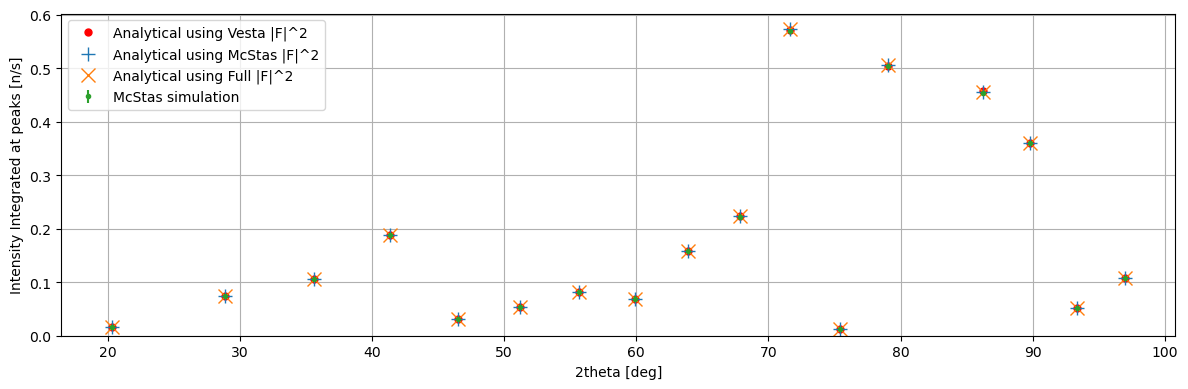

In [10]:

fig, ax = plt.subplots(figsize=(12,4), ncols=1)

# ax2 = ax.twinx()
ax.plot(nacalf_analytical[0], nacalf_analytical[1], 'r.',markersize=10,label='Analytical using Vesta |F|^2')
ax.plot(nacalf_McStas[0], nacalf_McStas[1], '+',markersize=10,label='Analytical using McStas |F|^2')
ax.plot(nacalf_Full[0], nacalf_Full[1], 'x',markersize=10,label='Analytical using Full |F|^2') # With fullprof
ax.errorbar(nacalf_analytical[0], data_int,yerr=errs, fmt='.', label='McStas simulation')

# ax2.errorbar(data.xaxis, data.Intensity, fmt='k-', label='McStas')


ax.legend()

ax.set(ylim=(0))
# ax2.set(ylim=(0,0.4))
ax.grid(True)
ax.set(xlabel="2theta [deg]",ylabel="Intensity Integrated at peaks [n/s]")
# ax2.set(ylabel="Intensity [n/s] simulation output")
fig.tight_layout()
# fig.savefig('')


In [16]:
# Copper
copper_anal = get_formfact('Copper.txt')
unit_cell_vol = 47.2416
rho = 1/unit_cell_vol # AA^-3
copper_anal = n_measured(flux, A, dist,h, unit_cell_vol, wavelength,r, copper_anal)


2.087121
1.8075


In [17]:
# Load the data and generate the simulated diffractogram
data = ms.load_data("../data/powder_cop")
data = data[-1]
print(data)
# split the data up into peaks
data_int = []
mask_areas = []
errs = []
for pos in copper_anal[0]:
    mask = (data.xaxis>(pos-1.5)) & (data.xaxis<(pos+1.5))
    mask_areas.append(data.xaxis[mask])
    intensity = np.sum(data.Intensity[mask])
    errs.append(np.sqrt(np.sum(data.Error**2)))
    data_int.append(intensity)


data_int = np.array(data_int)
print(f"Mcstas={data_int}\t Analytical={copper_anal[1]}\n")


McStasData: banana_mon type: 1D  I:9.79635 E:0.0189612 N:282070.0
Mcstas=[5.99891387 3.79743472]	 Analytical=[6.01448351 3.78893367]



[Text(0.5, 0, '2theta [deg]'),
 Text(0, 0.5, 'Intensity [n/s] Analytical calculation')]

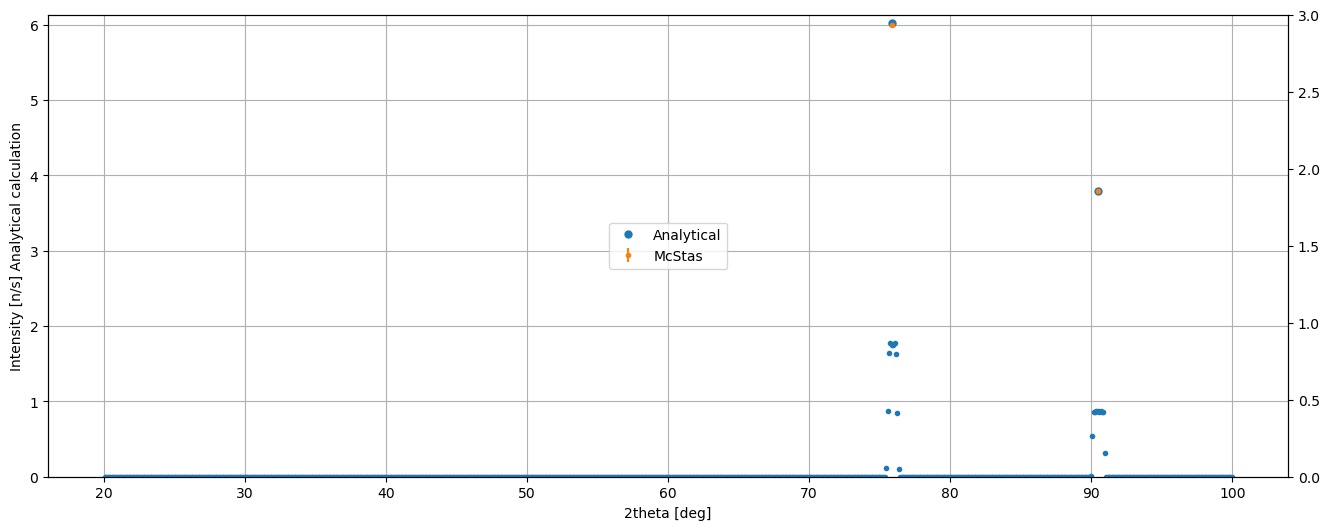

In [18]:
fig, ax = plt.subplots(figsize=(16,6), ncols=1)

ax2 = ax.twinx()
ax.plot(copper_anal[0], copper_anal[1], '.',markersize=10,label='Analytical')
ax.errorbar(copper_anal[0], data_int,yerr=errs, fmt='.', label='McStas')
ax2.errorbar(data.xaxis, data.Intensity, fmt='.', label='McStas')

ax.legend(loc='center')
# ax2.legend(loc='upper center')
ax.set(ylim=(0))
ax2.set(ylim=(0,3))
ax.grid(True)
ax.set(xlabel="2theta [deg]",ylabel="Intensity [n/s] Analytical calculation")
# ax2.set(ylabel="Intensity [n/s] McStas simulation")